In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['figure.dpi'] = 150
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['axes.titlepad'] = 10

In [2]:
# Load city metadata
city_info = pd.read_csv('/home/lpsha/s154446/fractality/data/city_external/city_info.csv')

# Load degree sequences for t50_a10
data_path = '/home/lpsha/s154446/fractality/data/city_degrees/t50_a10/'
city_degrees = {}
for fname in os.listdir(data_path):
    city_name = fname.replace('.npz', '')
    d = np.load(os.path.join(data_path, fname))
    city_degrees[city_name] = d['degree']

# Match cities to metadata
city_info['degrees'] = city_info['city'].map(city_degrees)
city_info = city_info.dropna(subset=['degrees'])
print(f"Matched {len(city_info)} cities with degree data")

# Create GDP bins
gdp_bins = [0, 5000, 15000, 30000, 50000, 200000]
gdp_labels = ['<5k', '5k-15k', '15k-30k', '30k-50k', '>50k']
city_info['gdp_group'] = pd.cut(city_info['country_gdp_per_capita_usd'], bins=gdp_bins, labels=gdp_labels)

city_info.head()

Matched 97 cities with degree data


,city,country,continent,latitude,longitude,population_city_proper,area_km2,population_density_per_km2,founding_era,street_pattern,country_gdp_per_capita_usd,climate_zone,elevation_m,coastal,degrees,gdp_group
0,"Copenhagen, Denmark",Denmark,Europe,55.68,12.57,794128,88,9024,medieval,organic,67803,Cfb,14,yes,"[4, 11, 3, 1, 3, 9, 9, 4, 2, 4, 2, 2, 3, 5, 1,...",>50k
1,"Luxembourg City, Luxembourg",Luxembourg,Europe,49.61,6.13,128514,52,2472,medieval,organic,126598,Cfb,302,no,"[3, 28, 2, 3, 3, 2, 1, 5, 2, 3, 1, 4, 4, 3, 7,...",>50k
2,"Perth, Australia",Australia,Oceania,-31.95,115.86,2085973,6418,325,colonial_19c,grid,51812,Csa,31,yes,"[12, 5, 32, 5, 6, 9, 4, 6, 3, 4, 3, 4, 11, 3, ...",>50k
3,"Santiago, Chile",Chile,South America,-33.45,-70.65,5614000,641,8758,colonial_16c,grid,16265,Csb,520,no,"[85, 100, 102, 11, 13, 3, 3, 5, 4, 4, 63, 5, 5...",15k-30k
4,Monaco,Monaco,Europe,43.74,7.42,39244,2,19622,medieval,organic,190512,Csa,62,yes,"[3, 15, 13, 3, 6, 16, 2, 10, 5, 7, 5, 9, 3, 6,...",>50k


In [7]:
city_info[city_info['founding_era']=='renaissance']

,city,country,continent,latitude,longitude,population_city_proper,area_km2,population_density_per_km2,founding_era,street_pattern,country_gdp_per_capita_usd,climate_zone,elevation_m,coastal,degrees,gdp_group
60,"Valletta, Malta",Malta,Europe,35.9,14.51,5827,1,5827,renaissance,grid,33486,Csa,56,yes,"[11, 13, 16, 11, 15, 4, 3, 10, 4, 11, 4, 4, 6,...",30k-50k


In [3]:
def plot_degree_grouped(df, group_col, title, cmap_name='tab10', ncols=3):
    """Plot degree distributions grouped by a categorical column.
    
    One subplot per group value. Each city shown in light color,
    aggregate for the group shown in bold.
    """
    groups = df[group_col].dropna().unique()
    groups = sorted(groups, key=str)
    n = len(groups)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6*ncols, 4.5*nrows), dpi=150)
    axs = np.atleast_2d(axs)
    cmap = plt.get_cmap(cmap_name)
    
    for idx, group in enumerate(groups):
        row, col = divmod(idx, ncols)
        ax = axs[row, col]
        subset = df[df[group_col] == group]
        color = cmap(idx / max(len(groups)-1, 1))
        
        full = np.array([])
        for _, city_row in subset.iterrows():
            d = city_row['degrees']
            full = np.append(full, d)
            if d.max() < 2:
                continue
            nbins = max(len(np.unique(d)), 2)
            y, x = np.histogram(d, bins=np.logspace(0, np.log10(d.max()), nbins), density=True)
            x = x[:-1]
            mask = y != 0
            if mask[:-1].sum() > 0:
                ax.plot(x[mask][:-1], y[mask][:-1], alpha=0.2, color=color, linewidth=0.8)
        
        # Aggregate
        if len(full) > 0 and full.max() >= 2:
            nbins = max(len(np.unique(full)), 2)
            y, x = np.histogram(full, bins=np.logspace(0, np.log10(full.max()), nbins), density=True)
            x = x[:-1]
            mask = y != 0
            if mask[:-1].sum() > 0:
                ax.plot(x[mask][:-1], y[mask][:-1], alpha=1, color=color, linewidth=2.5, zorder=5)
        
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('k')
        ax.set_ylabel('p(k)')
        ax.set_title(f'{group} (n={len(subset)})', fontsize=13)
        ax.set_xlim(right=1000)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.yaxis.set_minor_formatter(plt.NullFormatter())
    
    # Hide unused axes
    for idx in range(n, nrows * ncols):
        row, col = divmod(idx, ncols)
        axs[row, col].set_visible(False)
    
    fig.suptitle(f'Degree Distribution (t=50, a=10) — grouped by {title}', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

In [4]:
def plot_degree_overlay(df, group_col, title, cmap_name='tab10'):
    """Overlay aggregate degree distributions for each group on a single axis."""
    groups = df[group_col].dropna().unique()
    groups = sorted(groups, key=str)
    cmap = plt.get_cmap(cmap_name)
    
    fig, ax = plt.subplots(figsize=(8, 5.5), dpi=200)
    
    handles = []
    for idx, group in enumerate(groups):
        subset = df[df[group_col] == group]
        color = cmap(idx / max(len(groups)-1, 1))
        
        full = np.concatenate(subset['degrees'].values)
        if len(full) == 0 or full.max() < 2:
            continue
        nbins = max(len(np.unique(full)), 2)
        y, x = np.histogram(full, bins=np.logspace(0, np.log10(full.max()), nbins), density=True)
        x = x[:-1]
        mask = y != 0
        if mask[:-1].sum() > 0:
            ax.plot(x[mask][:-1], y[mask][:-1], color=color, linewidth=2, alpha=0.85)
            handles.append(Line2D([0], [0], color=color, linewidth=2, label=f'{group} (n={len(subset)})'))
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('k')
    ax.set_ylabel('p(k)')
    ax.set_title(f'Aggregate Degree Distribution by {title}', loc='left')
    ax.set_xlim(right=1000)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.set_minor_formatter(plt.NullFormatter())
    ax.legend(handles=handles, loc='best', frameon=False)
    plt.tight_layout()
    plt.show()

## 1. Founding Era

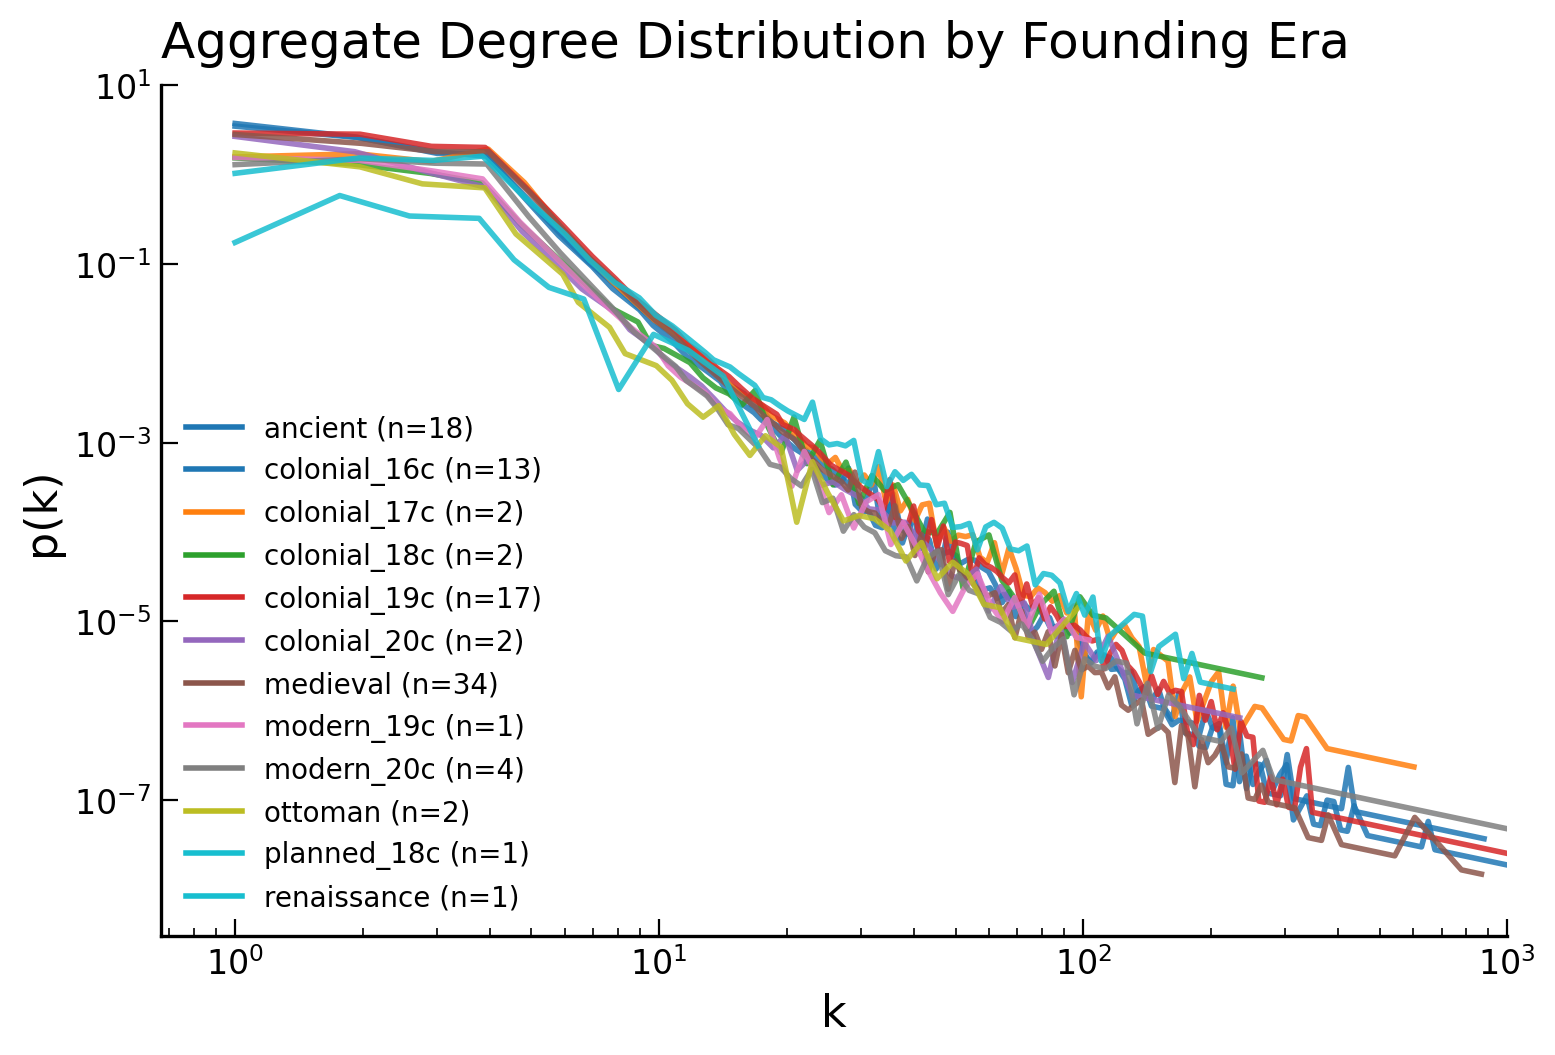

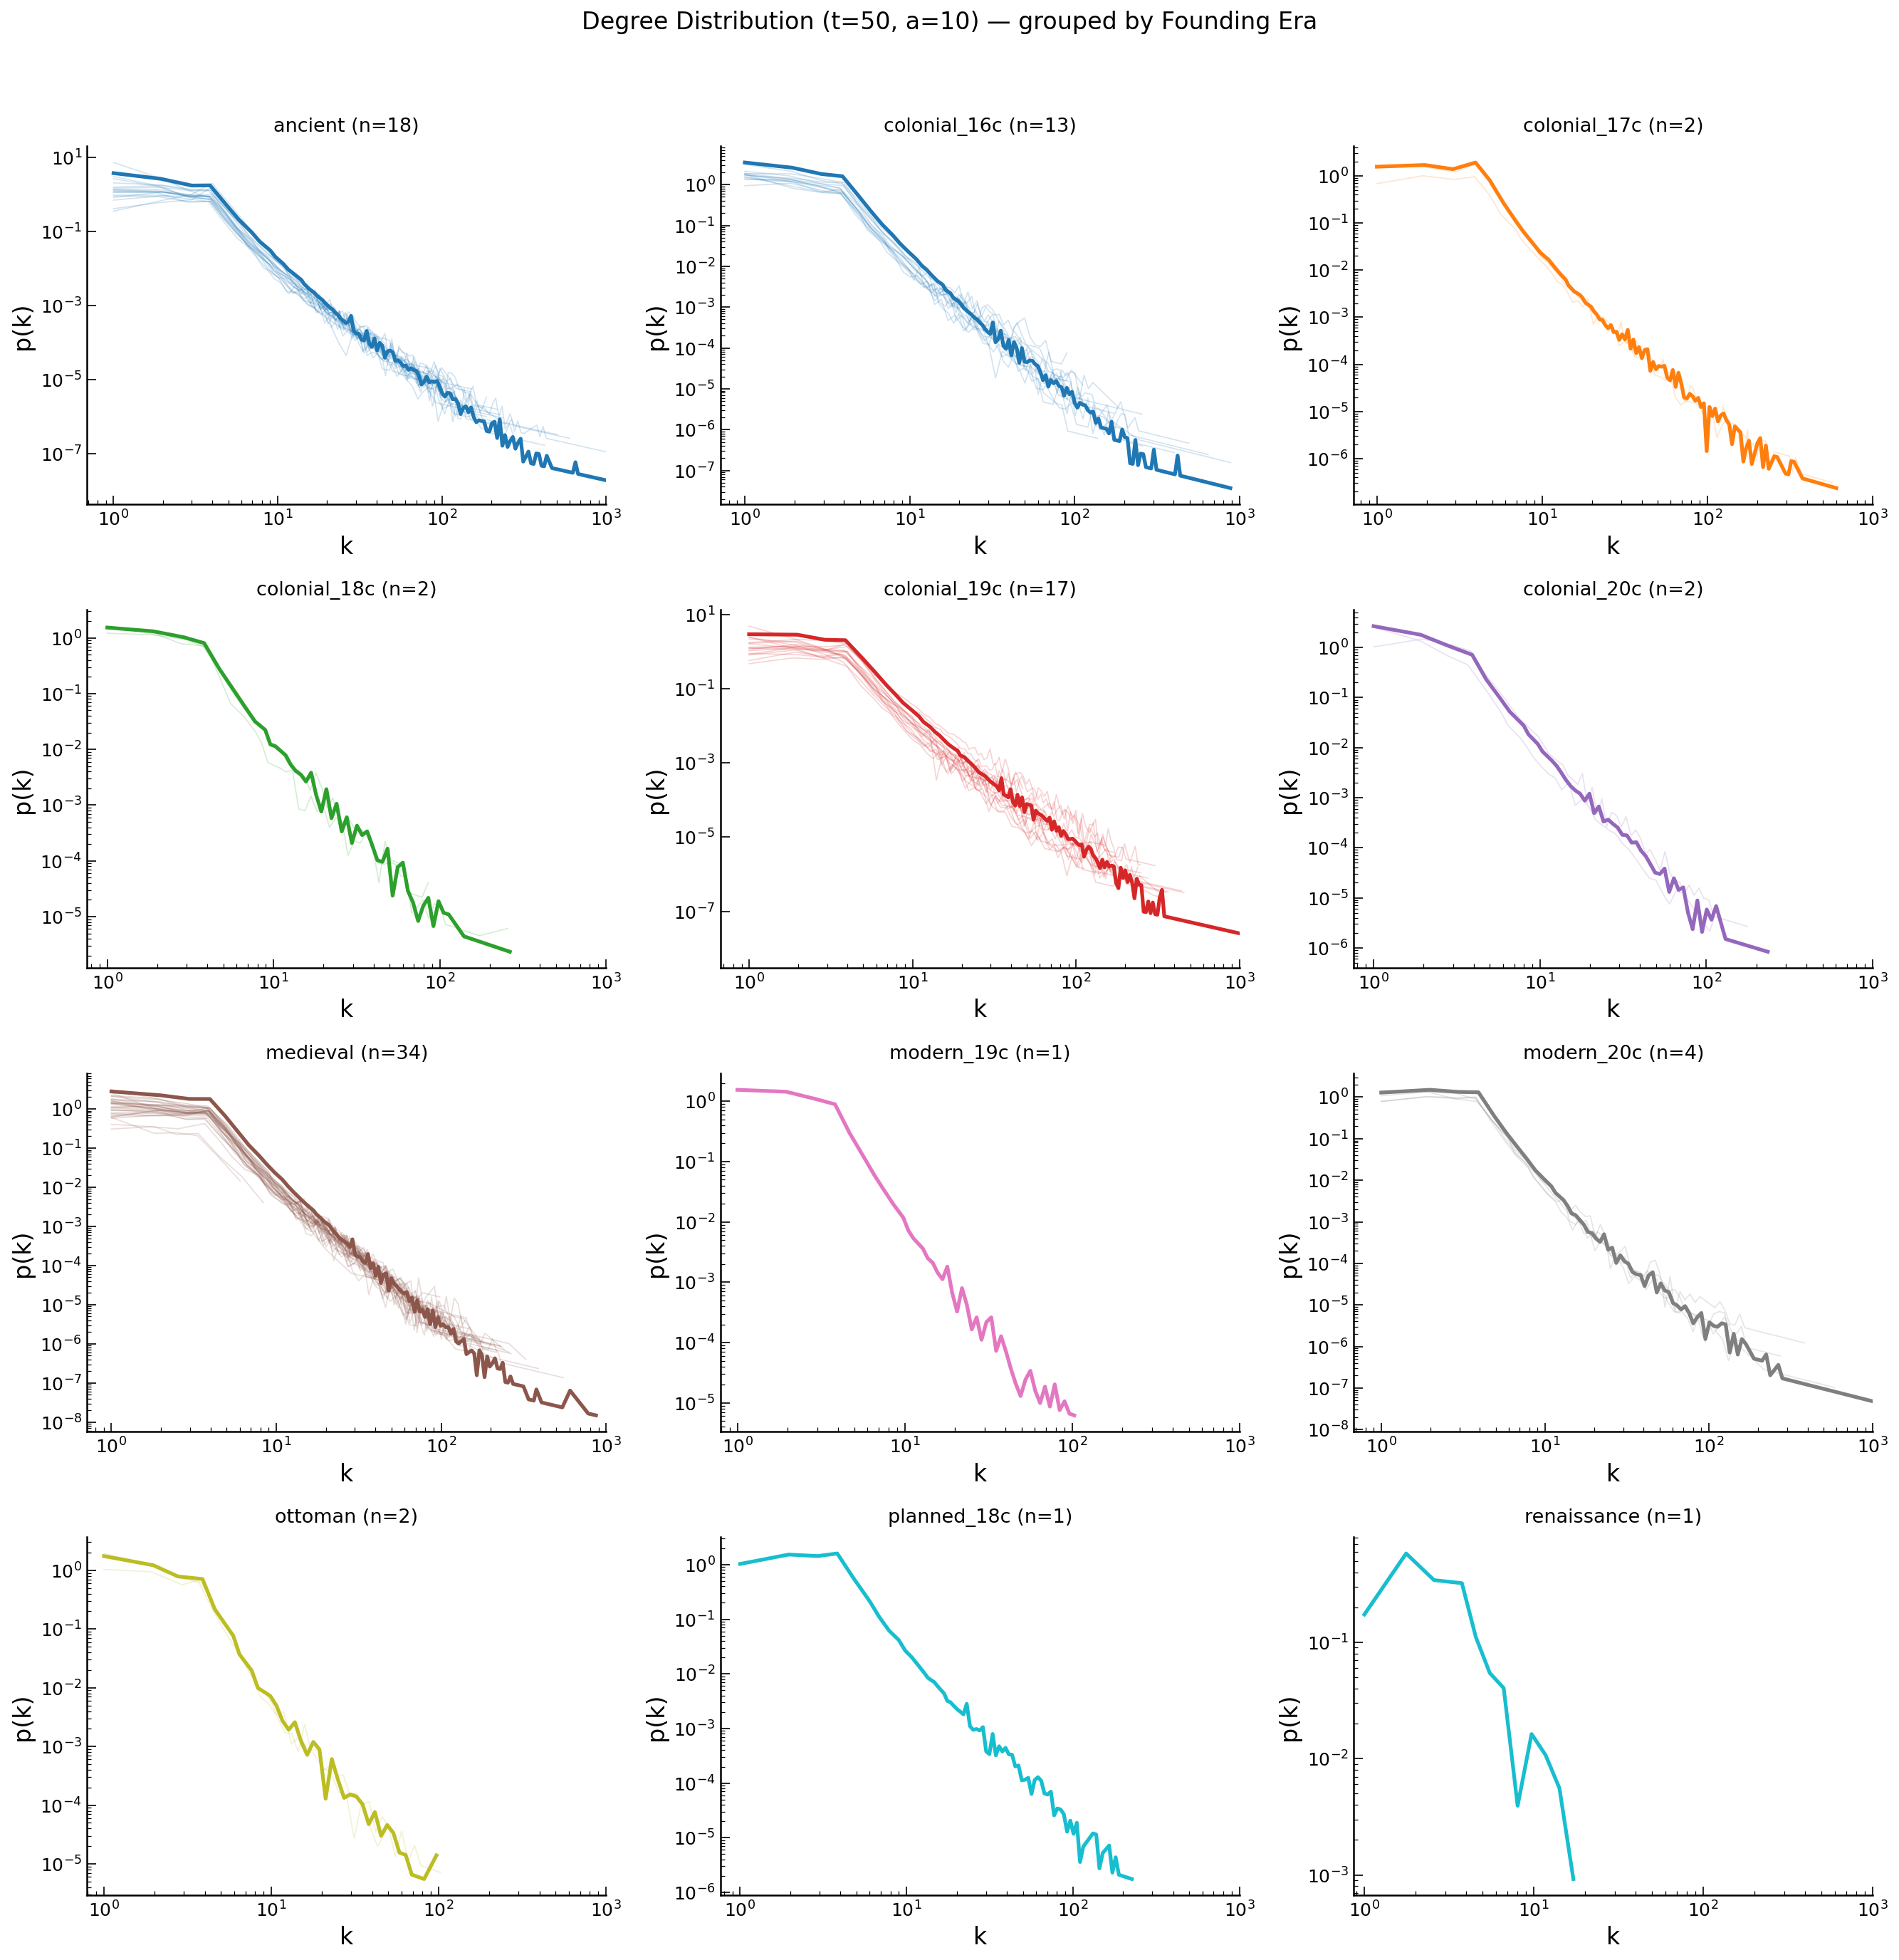

In [5]:
plot_degree_overlay(city_info, 'founding_era', 'Founding Era')
plot_degree_grouped(city_info, 'founding_era', 'Founding Era')

## 2. Street Pattern

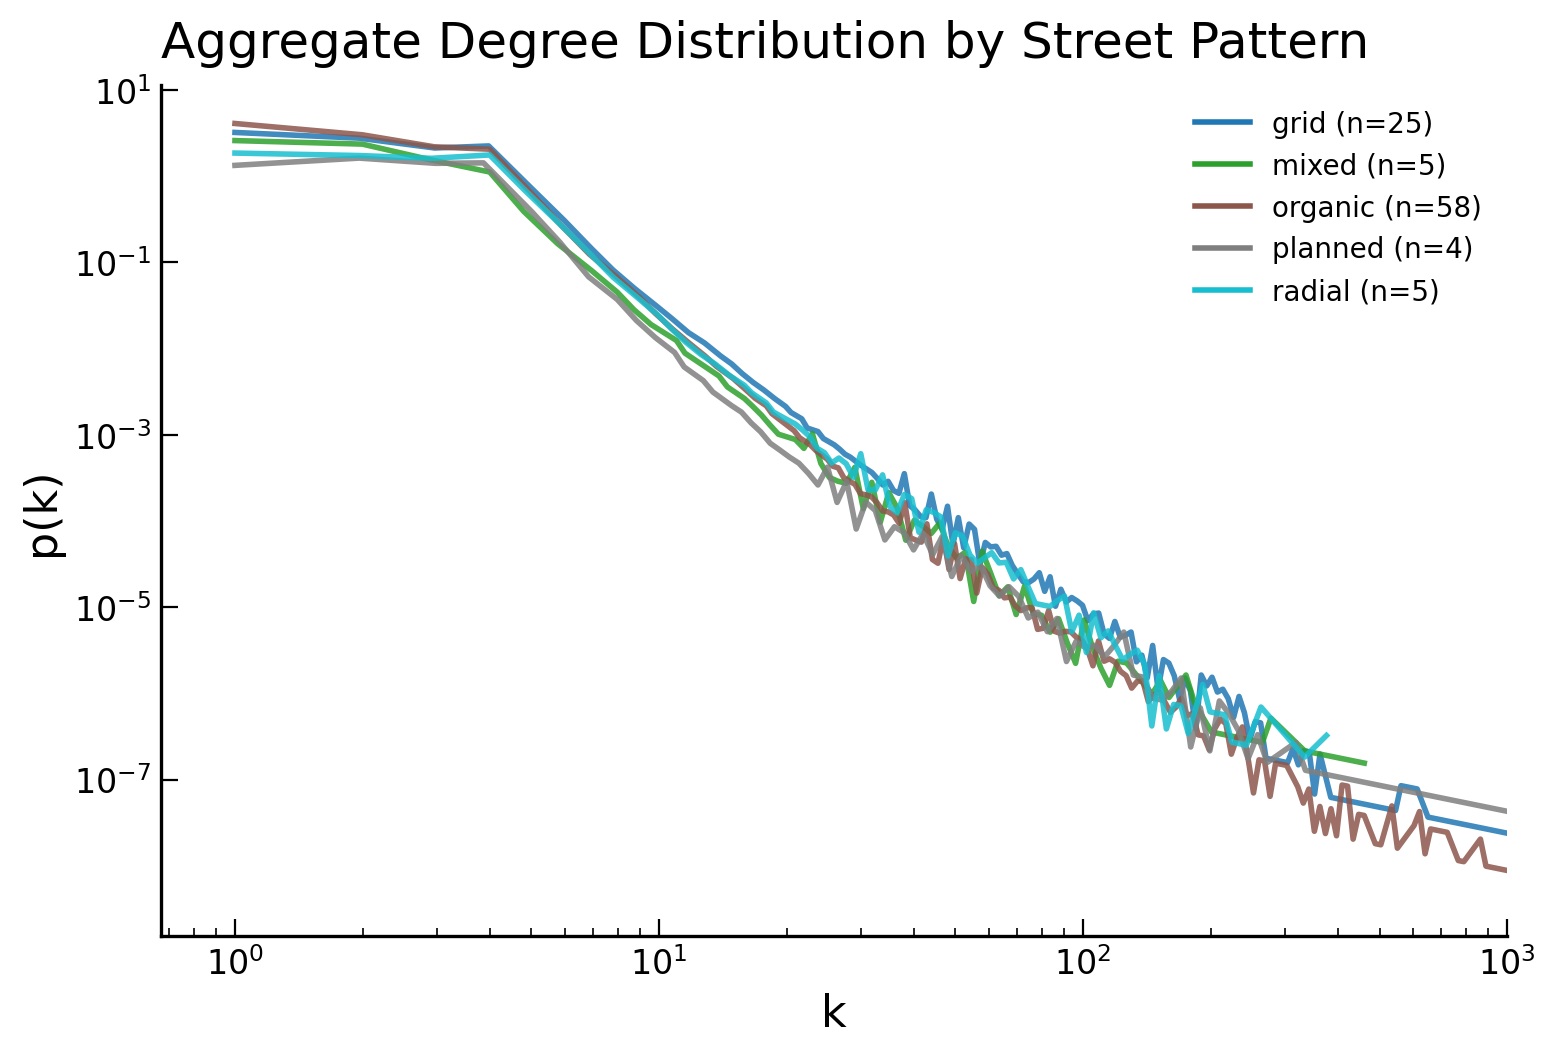

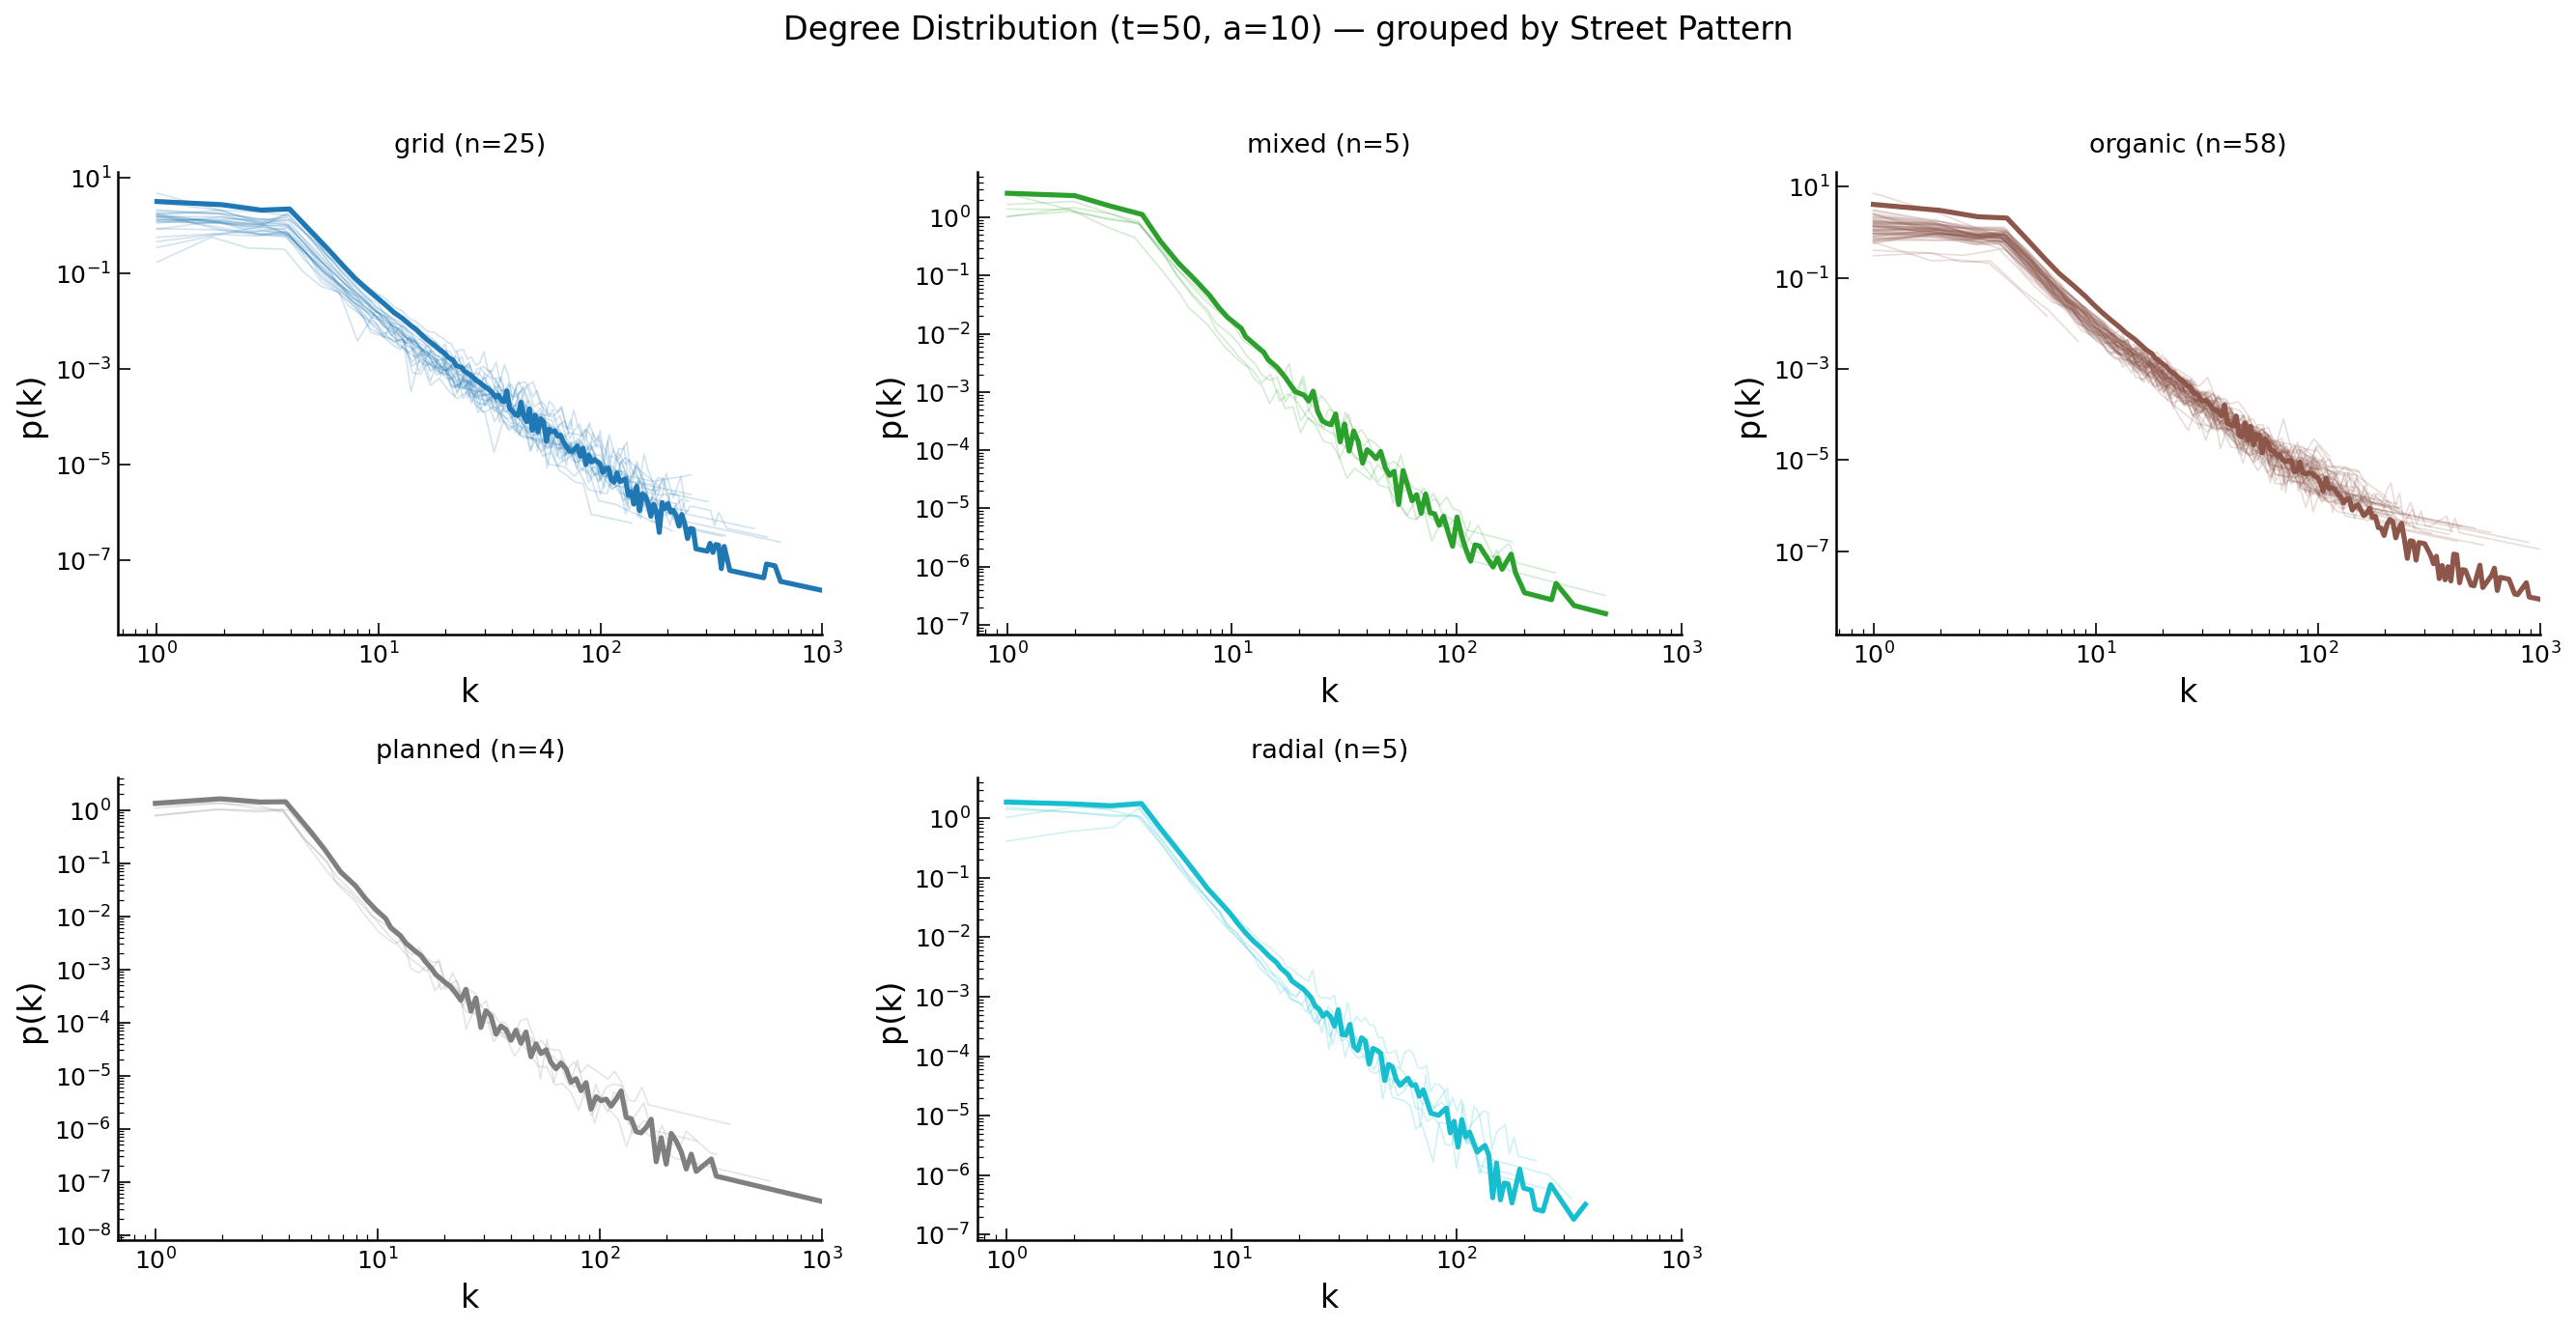

In [6]:
plot_degree_overlay(city_info, 'street_pattern', 'Street Pattern')
plot_degree_grouped(city_info, 'street_pattern', 'Street Pattern')

## 3. Coastal Status

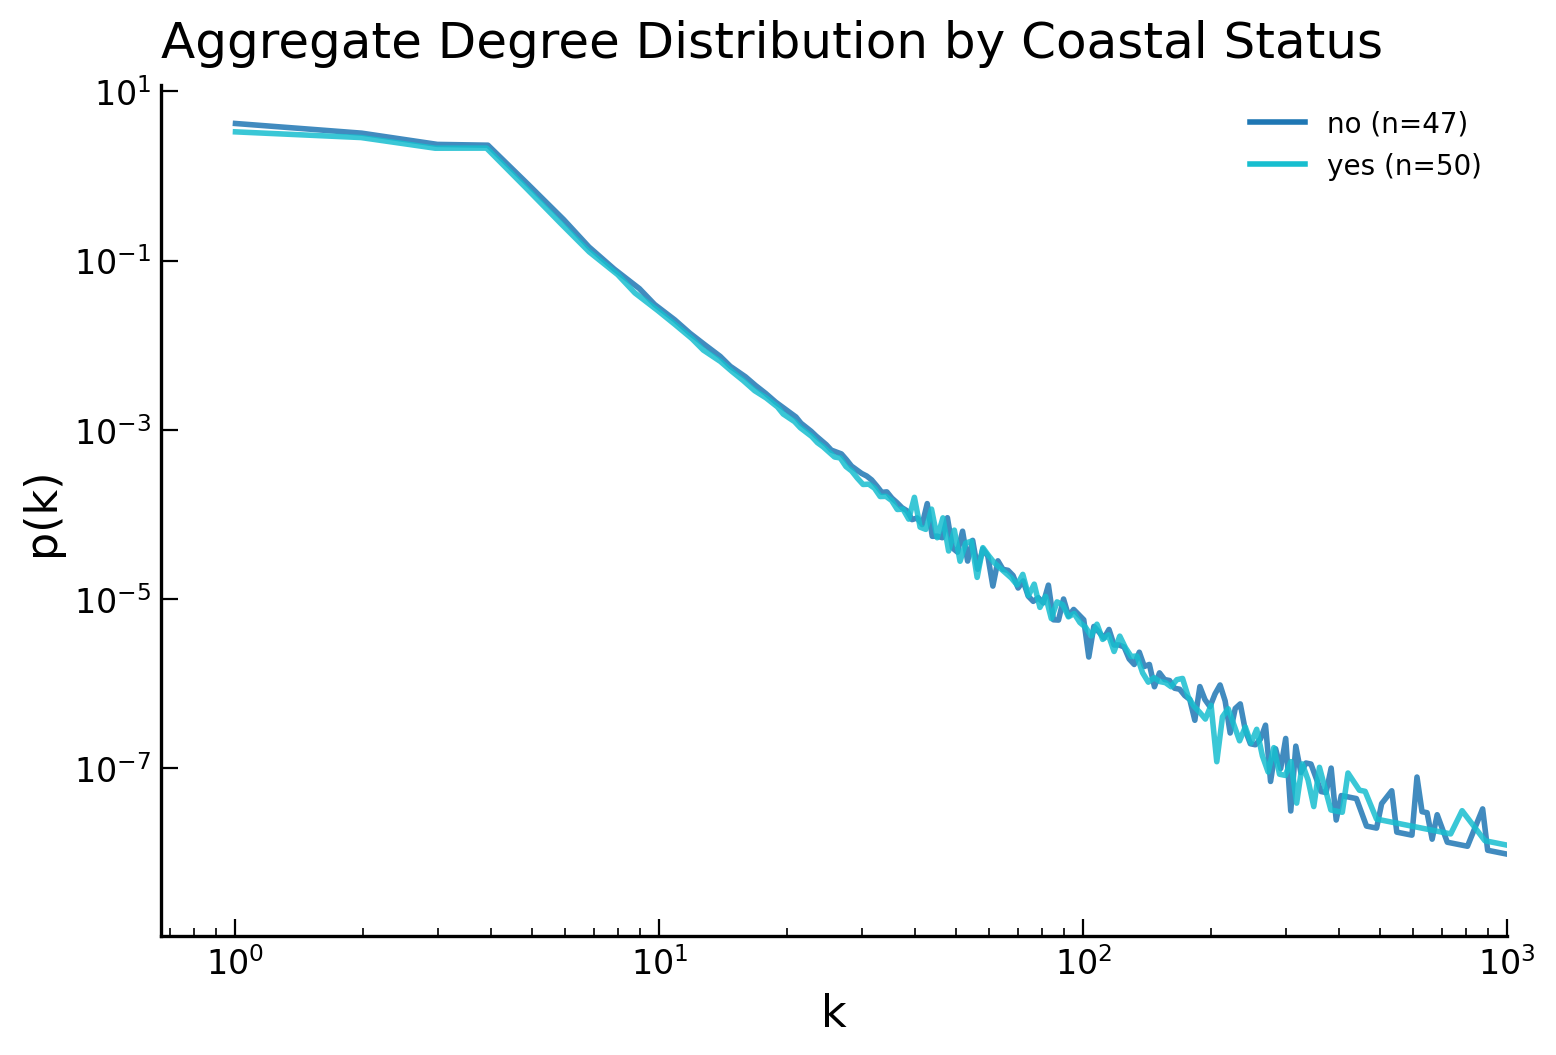

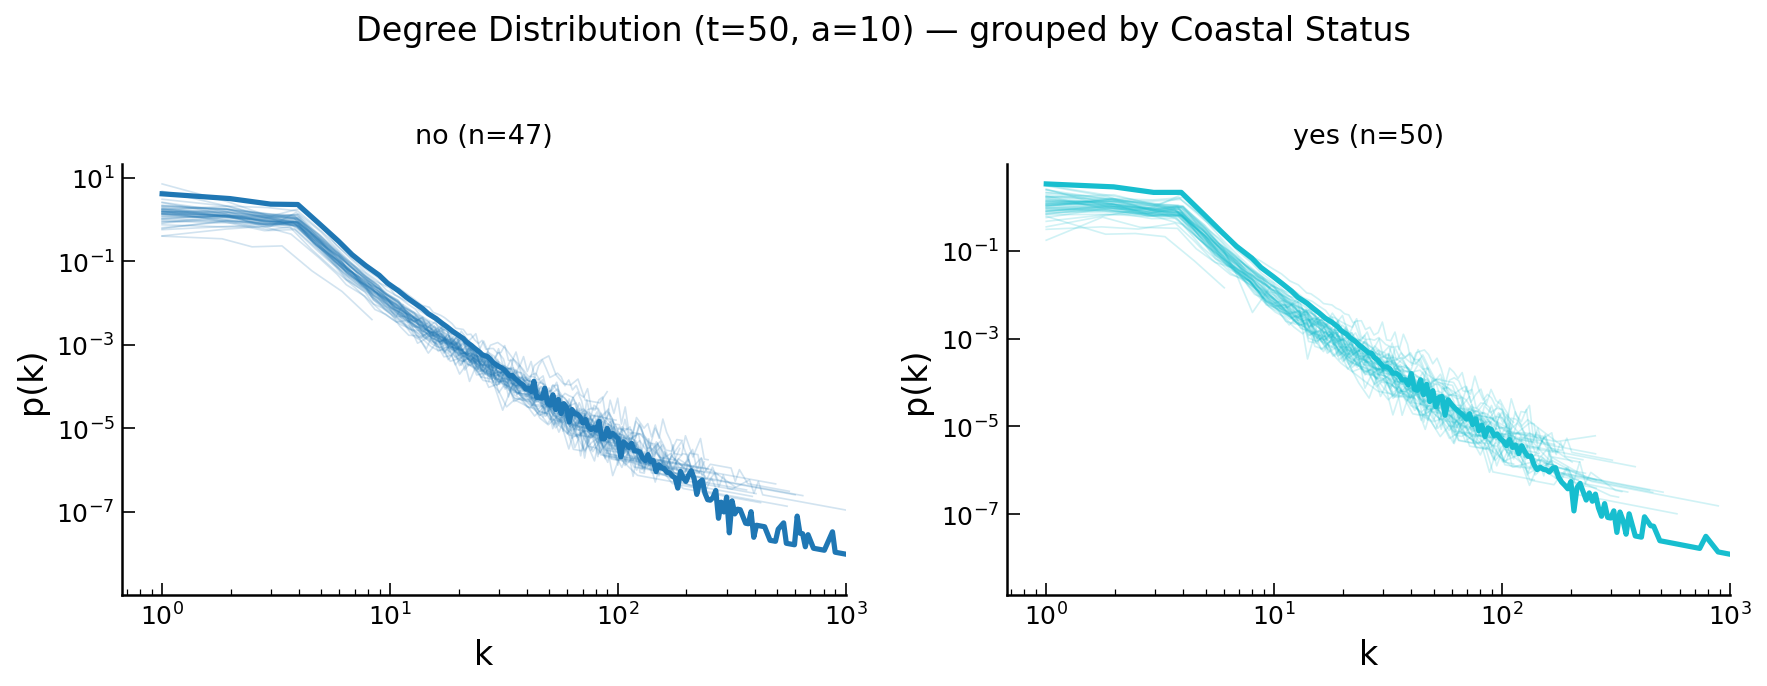

In [7]:
plot_degree_overlay(city_info, 'coastal', 'Coastal Status')
plot_degree_grouped(city_info, 'coastal', 'Coastal Status', ncols=2)

## 4. Continent

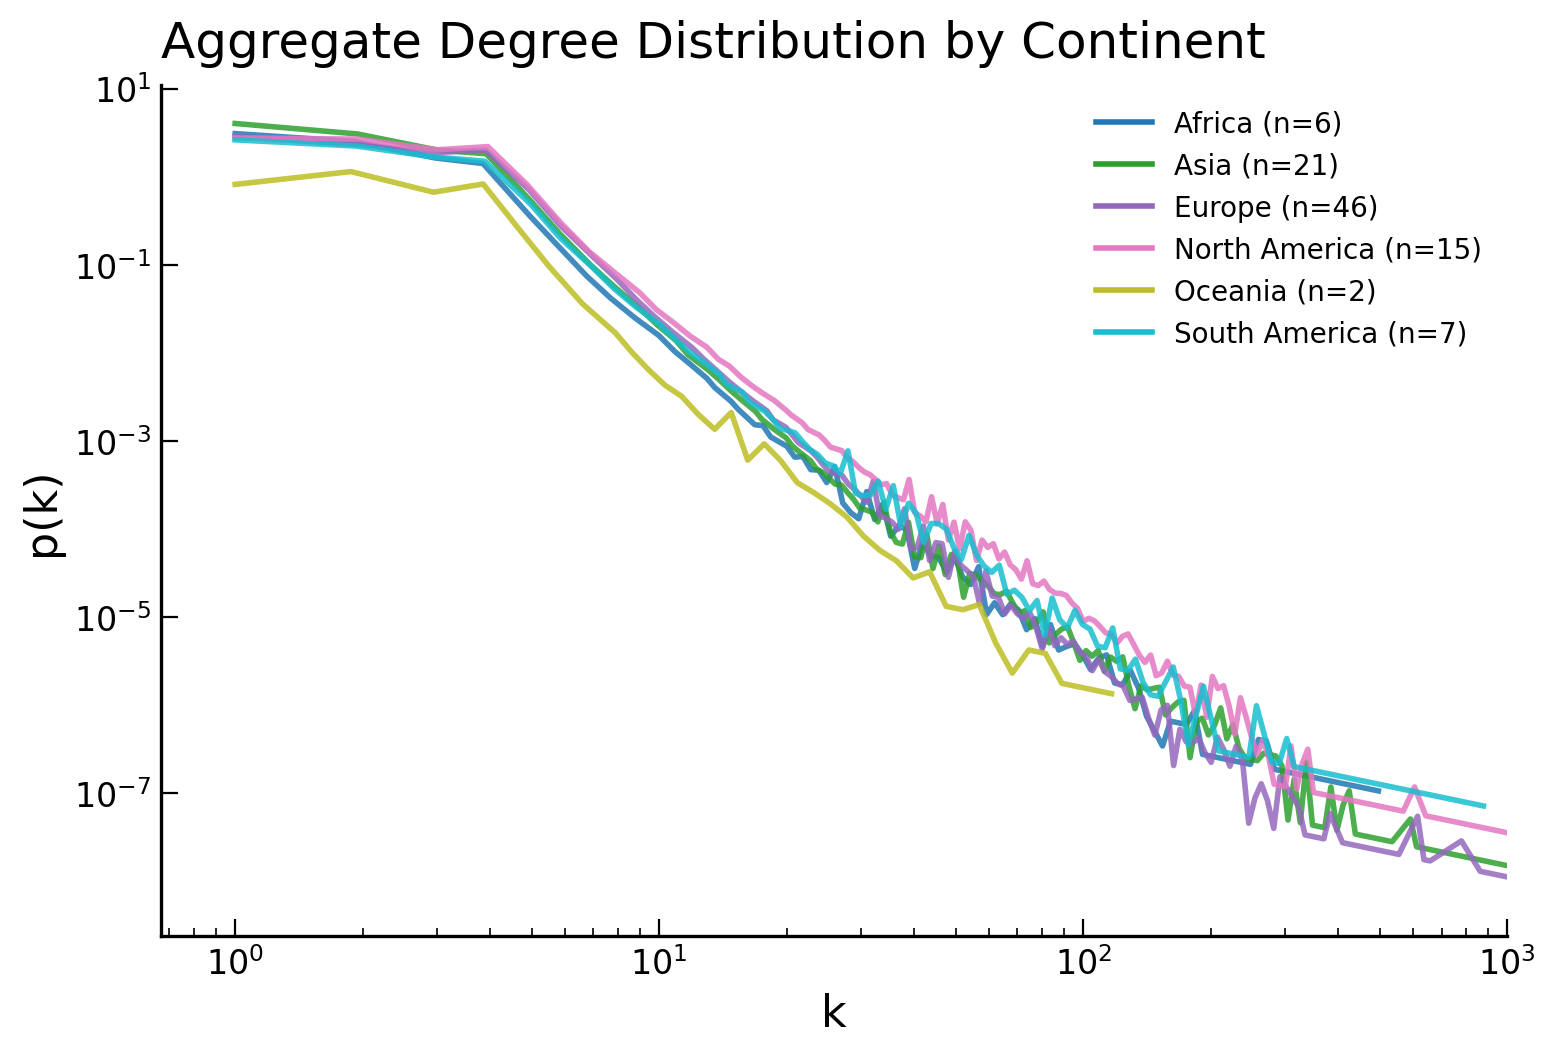

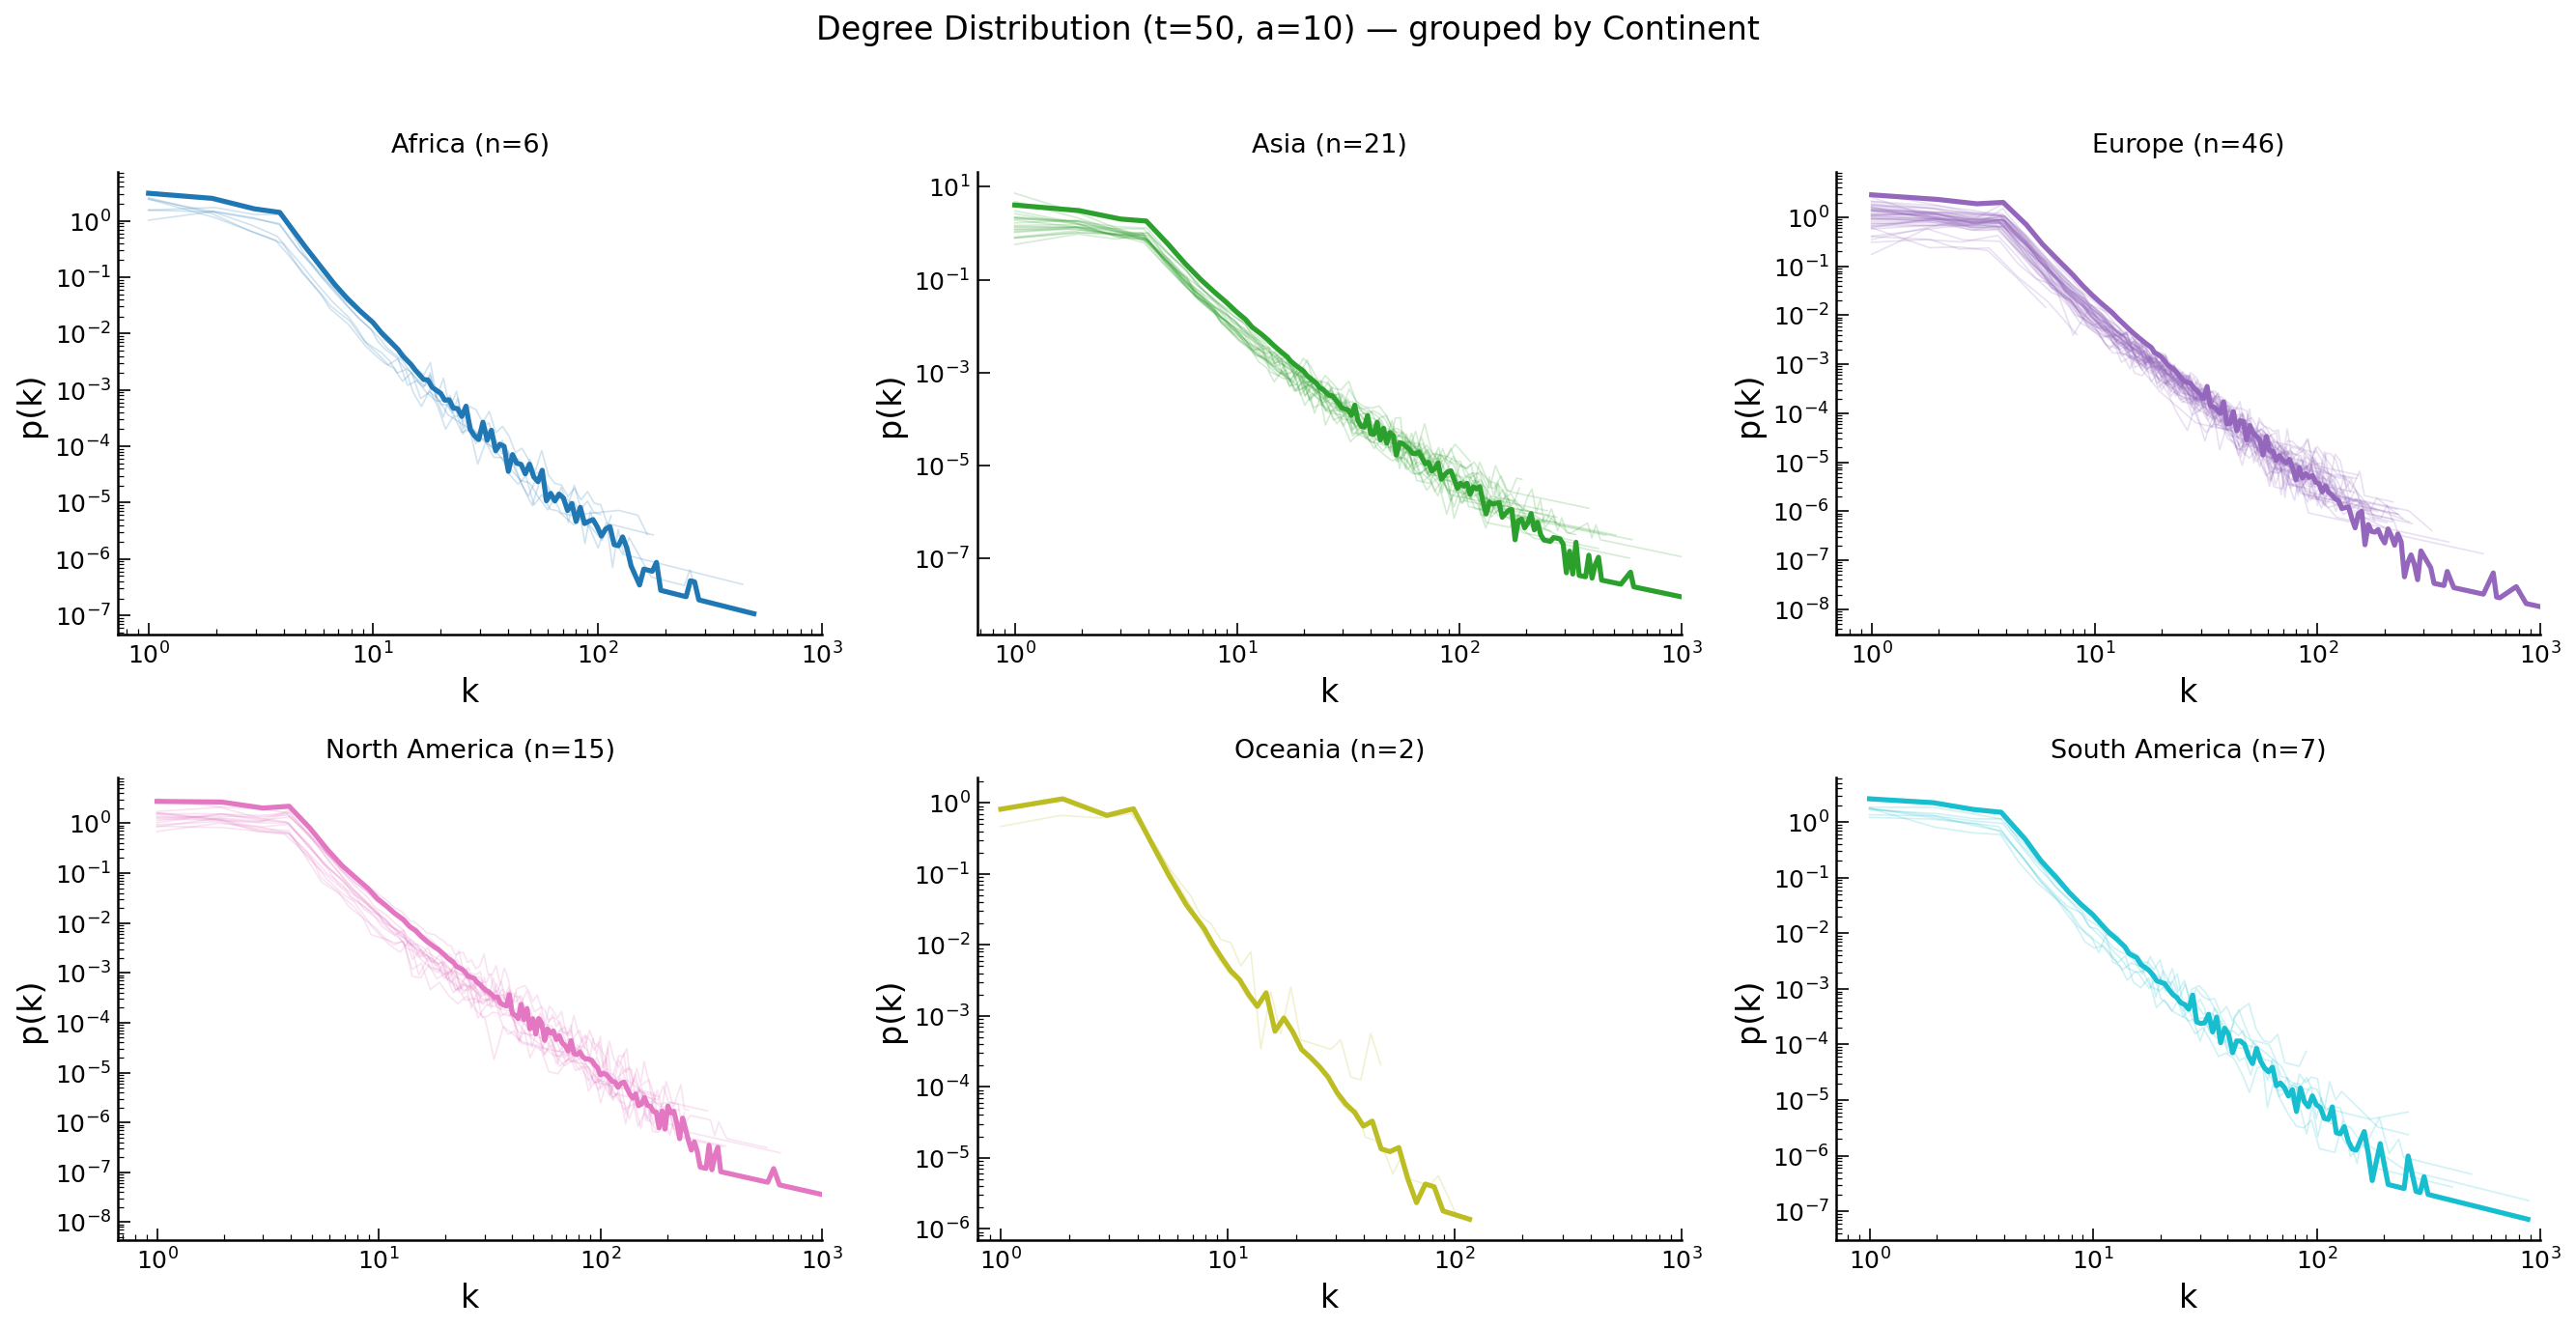

In [8]:
plot_degree_overlay(city_info, 'continent', 'Continent')
plot_degree_grouped(city_info, 'continent', 'Continent')

## 5. Climate Zone

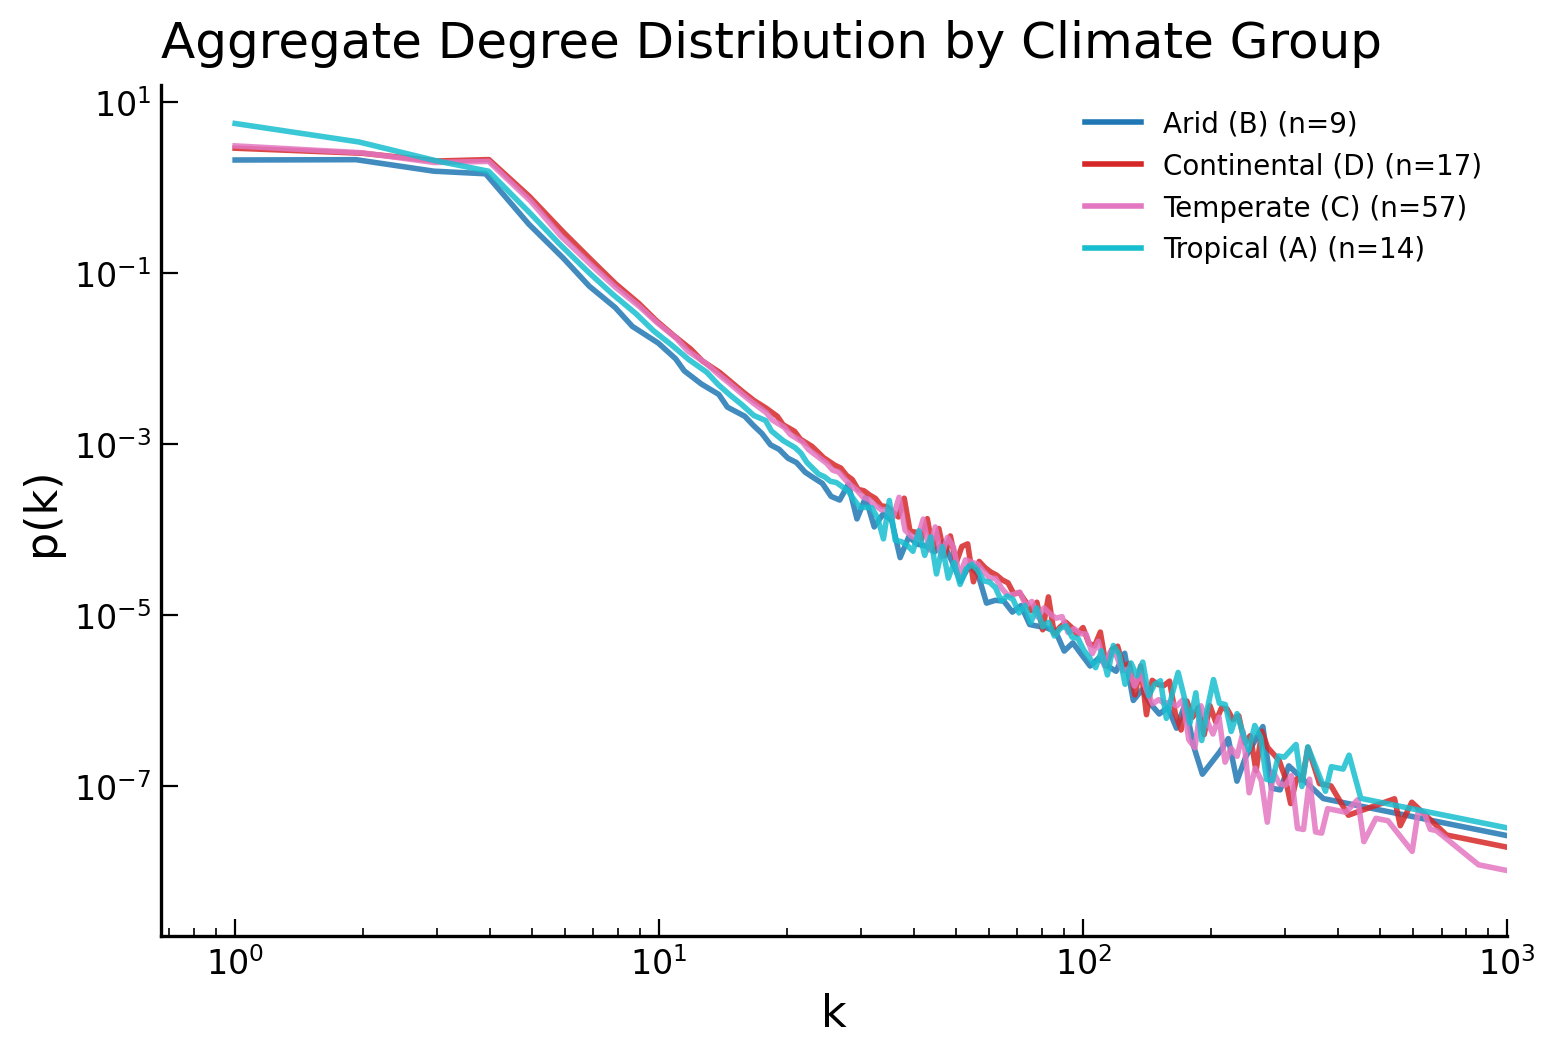

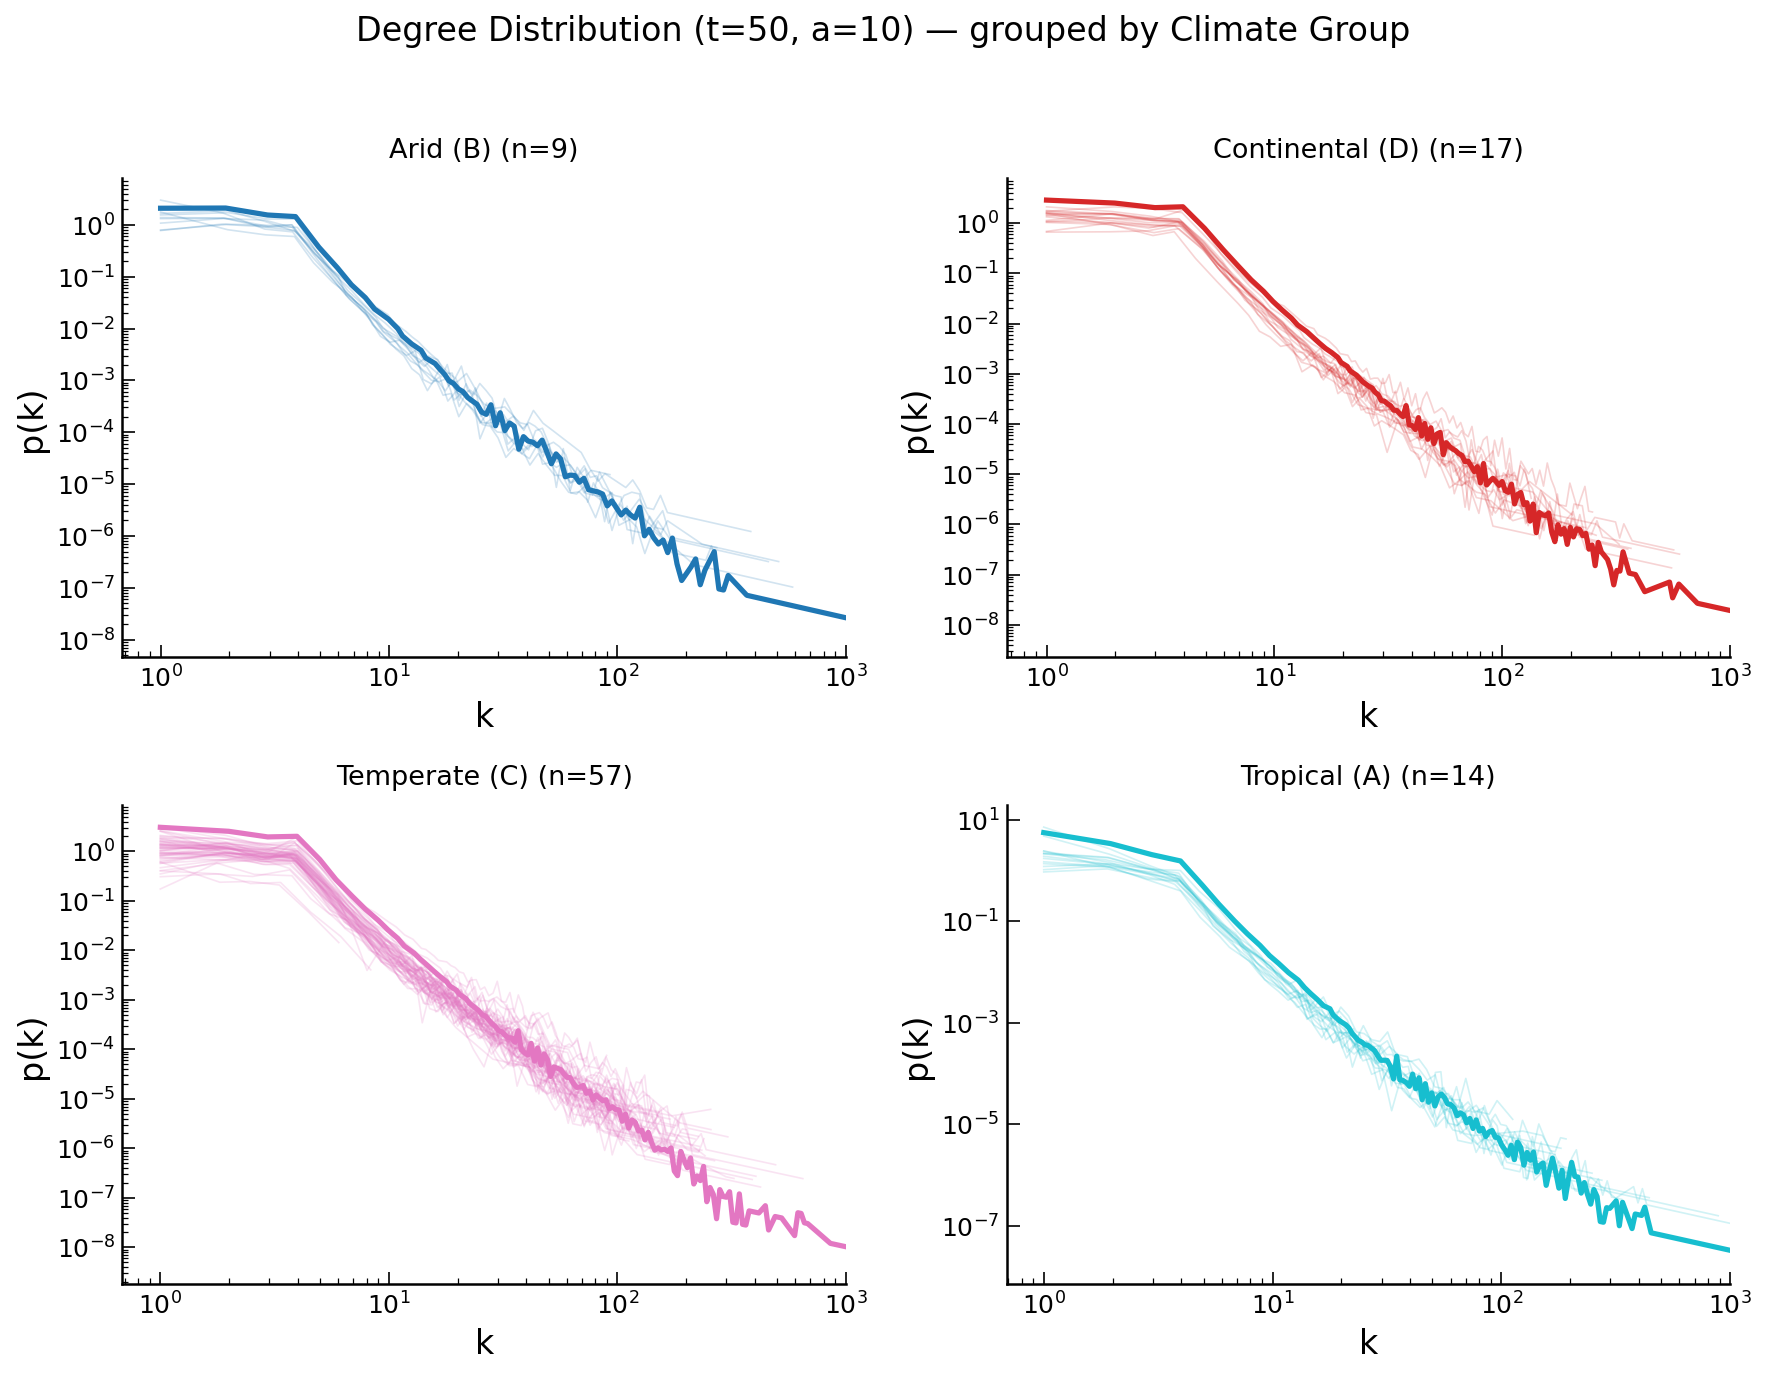

In [9]:
# Group by first letter of Koppen code (broad climate group)
climate_map = {'A': 'Tropical (A)', 'B': 'Arid (B)', 'C': 'Temperate (C)', 'D': 'Continental (D)'}
city_info['climate_group'] = city_info['climate_zone'].str[0].map(climate_map)

plot_degree_overlay(city_info, 'climate_group', 'Climate Group')
plot_degree_grouped(city_info, 'climate_group', 'Climate Group', ncols=2)

## 6. GDP per Capita (grouped)

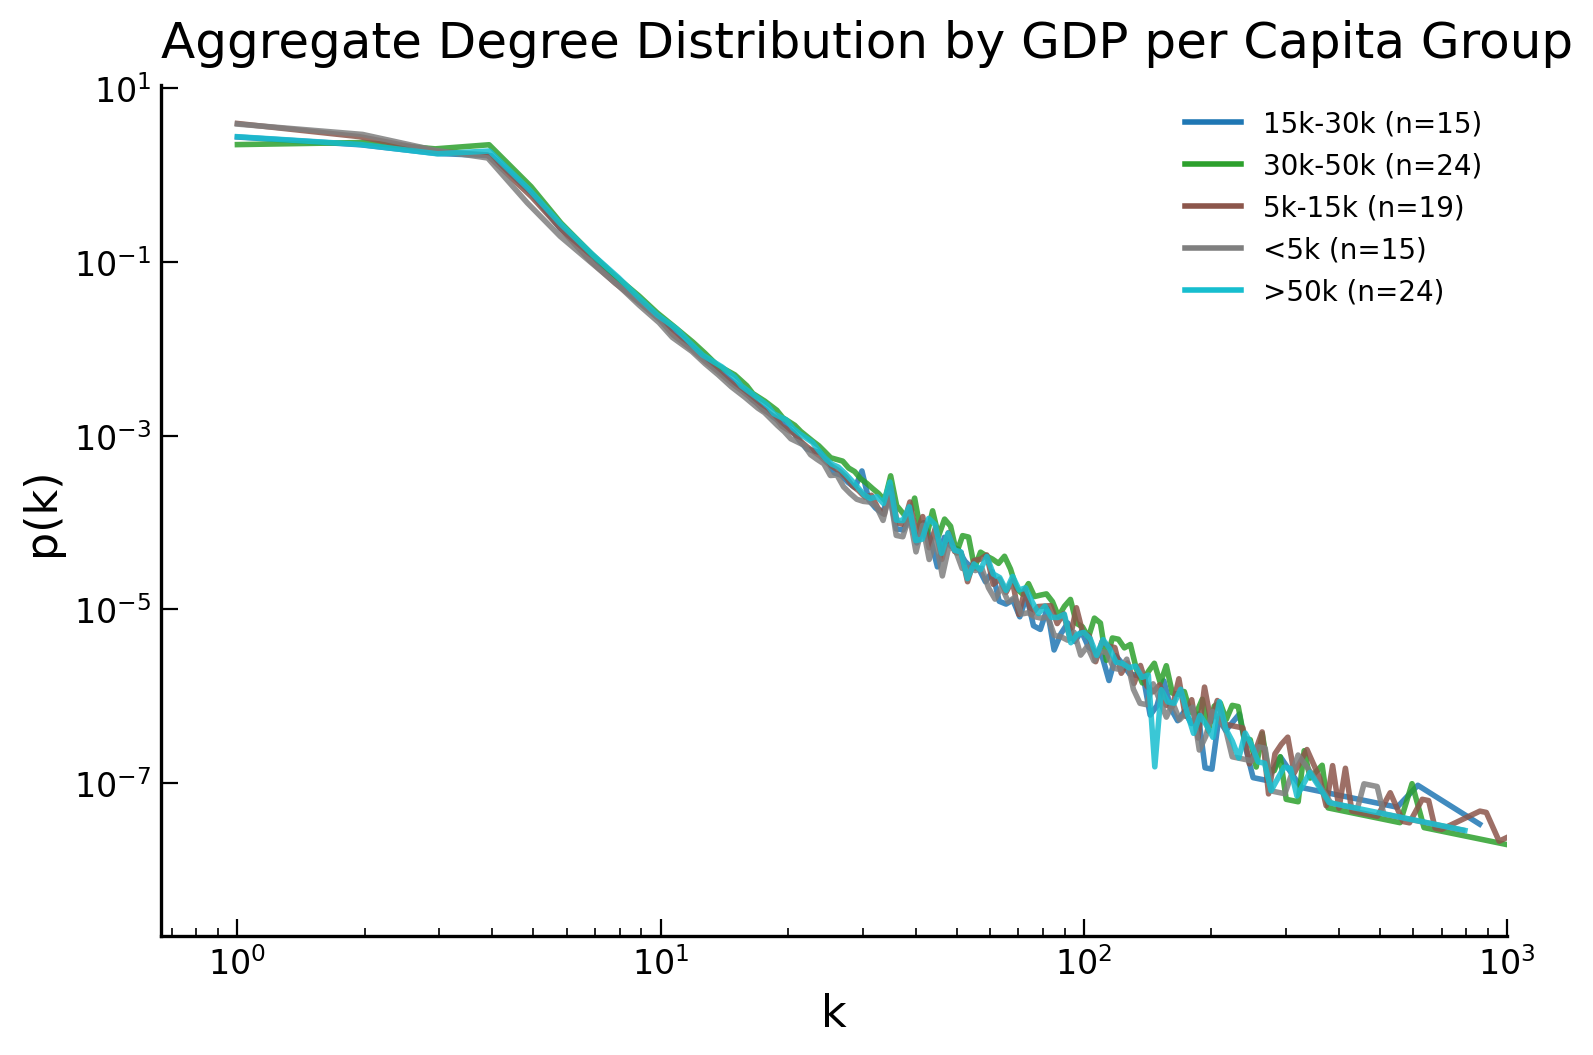

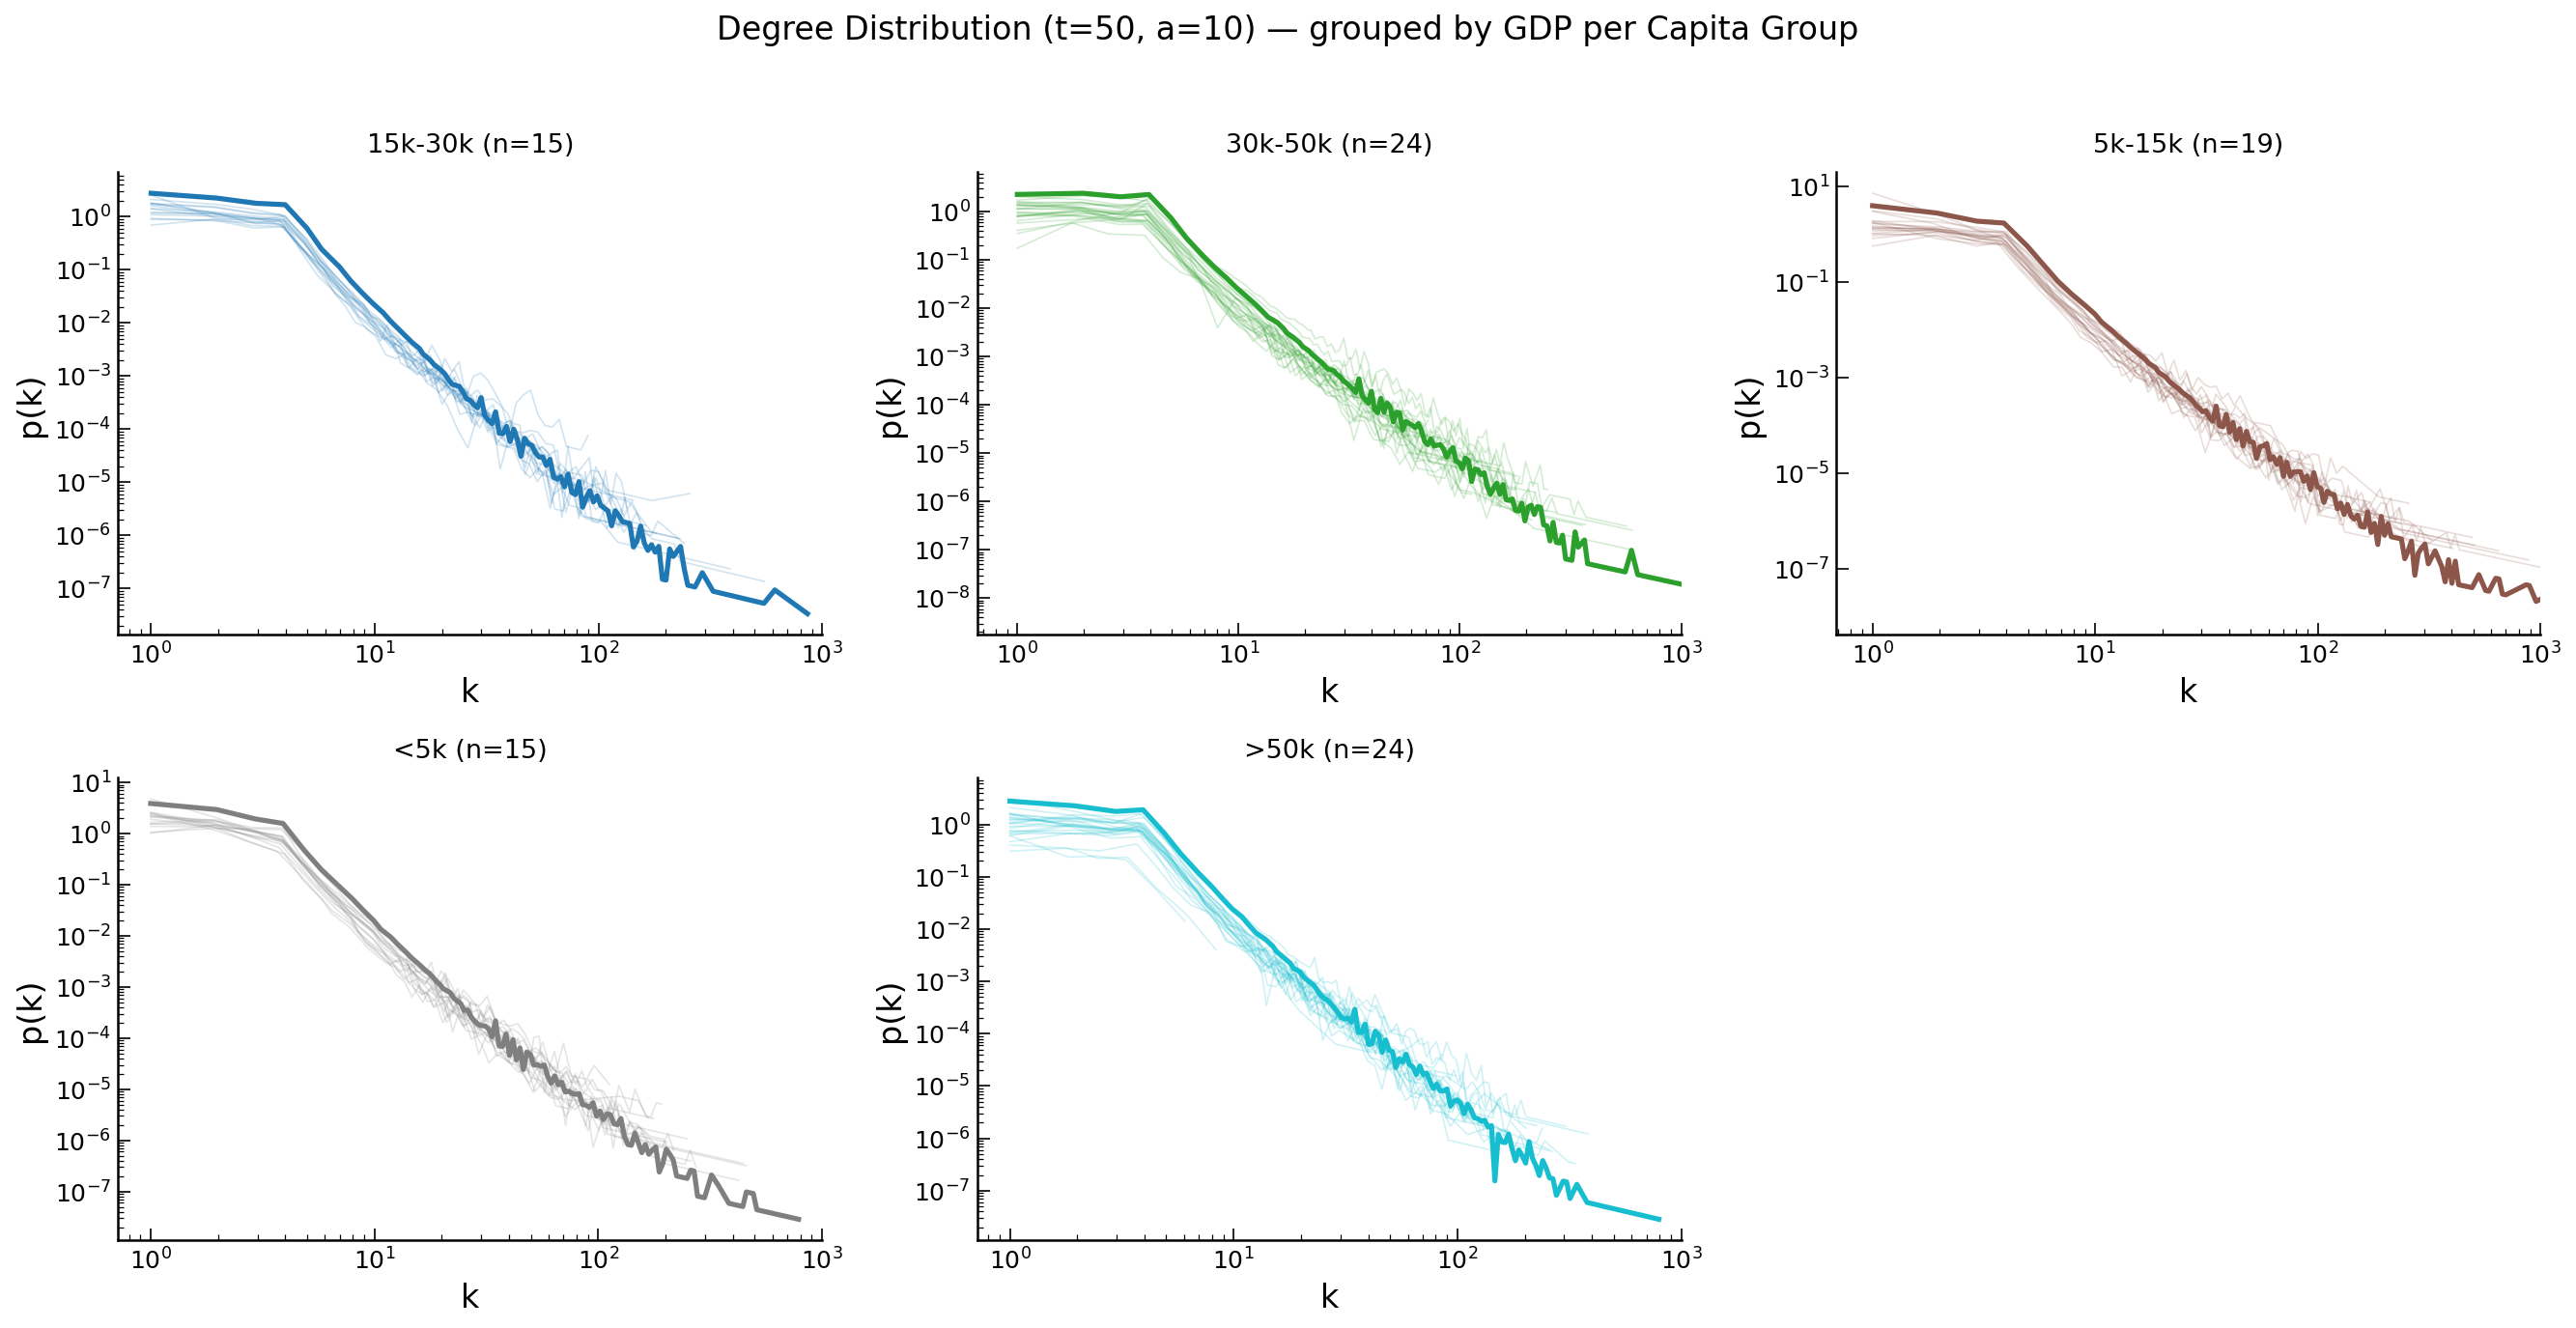

In [10]:
plot_degree_overlay(city_info, 'gdp_group', 'GDP per Capita Group')
plot_degree_grouped(city_info, 'gdp_group', 'GDP per Capita Group')